# Using the CCI Sea State subsetting interface

The ESA CCI Sea State project provides a web interface and API to subset the different data time series. User can select their dataset, variables, area and period of interest, and download them in various formats or directly use them from their script.

The URL for this service is: https://cci-seastate.ifremer.fr/

This brings you to the following user interface (see screenshot below). Just select your extraction criteria and download the data or copy/paste the provided code snippet into your script or jupyter notebook.

![title](subsetter.png)

In the following we will select and read data over the Bay of Biscay (West of France) and import them in thenotebook as a pandas DataFrame. This code snipped is directly copied from the web GUI. Simple as that!

In [32]:
%%time
import requests
import io
import pickle
import json
import pandas as pd


url = "https://cci-seastate.ifremer.fr/download_data"

area = {'west' : -5.614, 'south' : 46.988, 'east' : -4.131 , 'north' : 47.798}

variable_extent = ["bathymetry", "cycle", "distance_to_coast", "lat", "lon", "relative_pass", "satellite", "swh", "swh_adjusted", "swh_denoised", "swh_uncertainty", "time"]

temporal_extent = ["1991-08-03 00:00", "2024-01-02 00:00"]

payload = {
    "area" : json.dumps(area),
    "temporal_extent" : json.dumps(temporal_extent),
    "variable_extent" : json.dumps(variable_extent),
    "program" : "l3_altimeter",
    "format" : "pandas"
}

response = requests.request("POST", url, data=payload, timeout=600).content
data = pickle.load(io.BytesIO(response))
# data is a pandas.core.frame.DataFrame() object


CPU times: user 1.42 s, sys: 297 ms, total: 1.72 s
Wall time: 39.4 s


We now have in `data` a pandas DataFrame with all the collected measurements within the area and time period:

In [33]:
print(data)

        swh_denoised  distance_to_coast  swh_adjusted  relative_pass  cycle  \
0           9.622751           752000.0      9.601735            NaN      1   
1           9.629886           747000.0      9.746735            NaN      1   
2           9.594657           743000.0      9.636736            NaN      1   
3           9.464070           738000.0      9.906735            NaN      1   
4           9.256510           734000.0      9.811735            NaN      1   
...              ...                ...           ...            ...    ...   
490736      2.374578           679000.0      2.583595            NaN     78   
490737      2.389965           686000.0      2.893221            NaN     78   
490738      2.385899           693000.0      2.159902            NaN     78   
490739      2.345958           698000.0      2.069340            NaN     78   
490740      2.332614           705000.0      2.273203            NaN     78   

                             time        lat  bathy

We can display all SWH (from `swh_denoised` variable) data at once, which is pretty noisy:

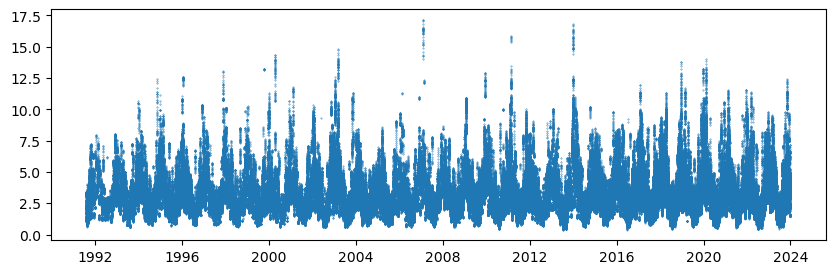

In [34]:
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(10,3))
plt.scatter(data['time'], data['swh_denoised'], s=0.1)

Using simple pandas function, we can quickly average the data as monthly means and display the resulting time series:

<Axes: xlabel='time'>

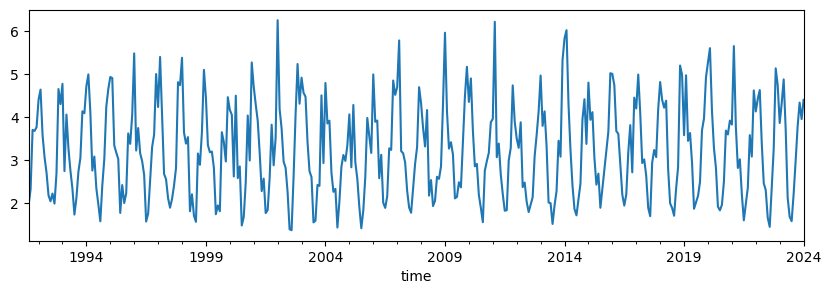

In [35]:
fig = plt.figure(figsize=(10,3))

data.groupby(pd.Grouper(key='time', axis=0, freq='MS')).swh_denoised.mean().plot()